# 模块 8 节点壳：状态机（`/state_machine`）调用示例

对应 `catkin_ws/src/uav_tracking/scripts/state_machine_node.py`，演示**壳 ↔ 核**如何协作：

- **核**（`lib/state_machine.py` → 软链到 `code/state_machine.py`）：`evaluate_visual_lock` / `evaluate_radar_lost` / `transition` 纯逻辑；
- **壳**（`state_machine_node.py`）：ROS 消息 ↔ `datatypes` 的转换 + 节拍 + 接线。

本 notebook 演示 3 部分：

| 场景 | 内容 |
|---|---|
| 1 | 消息 → `datatypes` 转换（`detections_from_msg` / `visual_tracks_from_msg` / `radar_tracks_from_msg` / `state_to_msg`） |
| 2 | 帧驱动：`step` 单拍判定，观察状态轨迹（方案 B：`/detections` 为节拍） |
| 3 | 节点接线与运行方式 |

> ⚠️ 本 notebook 依赖 ROS（`rospy` + 生成的 `uav_tracking.msg`），请在 Jupyter 内核选择器里选 **「ROS Noetic (Py3.8)」** 内核；
> ROS 环境需先 `source catkin_ws/devel/setup.bash`（该内核已预置）。

In [1]:
import os
import sys


def find_repo(start):
    """从 start 向上找到含 catkin_ws 的仓库根。"""
    p = os.path.abspath(start)
    for _ in range(6):
        if os.path.isdir(os.path.join(p, 'catkin_ws')):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(start)


REPO = find_repo('.')
CODE_DIR = os.path.join(REPO, 'code')
SCRIPTS_DIR = os.path.join(REPO, 'catkin_ws', 'src', 'uav_tracking', 'scripts')
for _p in (CODE_DIR, SCRIPTS_DIR):
    if _p not in sys.path:
        sys.path.insert(0, _p)

%matplotlib inline
import matplotlib.pyplot as plt

import state_machine as sm
from datatypes import DetectedTarget, Track, VisualTrack
from uav_tracking.msg import Detections, DetectedTarget as DetectedTargetMsg
from uav_tracking.msg import VisualTrackArray, VisualTrack as VisualTrackMsg
from uav_tracking.msg import TrackArray, Track as TrackMsg
import state_machine_node as node

print('REPO =', REPO)
print('ROS 消息导入 OK | N/M/K =', sm.N_VISUAL_LOCK, sm.M_VISUAL_LOST, sm.K_RADAR_LOST)

REPO = /home/demo/桌面/ai4
ROS 消息导入 OK | N/M/K = 3 3 5


## 1. 消息 → `datatypes` 转换

壳的第一个职责：把 ROS 消息拆成项目自定义数据类型（纯转换，驻 `datatypes`）。
`datatypes.DetectedTarget/VisualTrack/Track` 与 `uav_tracking.msg` 同名，壳内已给消息类型起别名。

In [2]:
# --- Detections ---
dm = Detections()
t = DetectedTargetMsg(); t.class_id = 0; t.confidence = 0.9; t.bbox = [0.0, 0.0, 100.0, 100.0]
dm.targets.append(t)
print('detections_from_msg ->', node.detections_from_msg(dm))

# --- VisualTrackArray ---
vm = VisualTrackArray()
vt = VisualTrackMsg(); vt.id = 1; vt.bbox = [0.0, 0.0, 100.0, 100.0]; vt.area_ratio = 0.05
vm.tracks.append(vt)
print('visual_tracks_from_msg ->', node.visual_tracks_from_msg(vm))

# --- TrackArray ---
rm = TrackArray()
rt = TrackMsg(); rt.id = 1; rt.position = [8.0, 3.0, 2.0]
rt.velocity = [0.0, 0.0, 0.0]; rt.covariance = [0.0] * 36; rt.age = 1
rm.tracks.append(rt)
print('radar_tracks_from_msg ->', node.radar_tracks_from_msg(rm))

# --- str -> std_msgs/String ---
print('state_to_msg ->', repr(node.state_to_msg(sm.STATE_VISUAL_LOCK).data))

detections_from_msg -> [DetectedTarget(class_id=0, confidence=0.9, bbox=(0.0, 0.0, 100.0, 100.0))]
visual_tracks_from_msg -> [VisualTrack(id=1, bbox=(0.0, 0.0, 100.0, 100.0), area_ratio=0.05)]
radar_tracks_from_msg -> [Track(id=1, position=(8.0, 3.0, 2.0), velocity=(0.0, 0.0, 0.0), covariance=(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0), age=1)]
state_to_msg -> 'VISUAL_LOCK'


## 2. 帧驱动：`step` 单拍判定

`step(state, counters, detections, visual_tracks, radar_tracks, ...)` 是壳里抽出的**单拍纯函数**
（便于单测），内部即 `evaluate_visual_lock` + `evaluate_radar_lost` + `transition`。
下面用一段脚本帧序列驱动它（方案 B：每帧即「一拍」），观察状态轨迹。

帧表列含义：`(阶段, 雷达航迹条数, 是否满足视觉锁定条件)`。

In [3]:
frames = [
    ('A 仅雷达',       1, False),
    ('B 视觉锁定条件', 1, True),
    ('B 视觉锁定条件', 1, True),
    ('B 视觉锁定条件', 1, True),   # 连续第 3 拍 → VISUAL_LOCK
    ('B 视觉保持',     1, True),
    ('C 视觉丢失',     1, False),
    ('C 视觉丢失',     1, False),
    ('C 视觉丢失',     1, False),  # 连续第 3 拍 → RADAR_GUIDE
    ('D 雷达丢失',     0, False),
    ('D 雷达丢失',     0, False),
    ('D 雷达丢失',     0, False),
    ('D 雷达丢失',     0, False),
    ('D 雷达丢失',     0, False),  # 连续第 5 拍 → SEARCH/RTH
    ('E 雷达恢复',     1, False),  # → RADAR_GUIDE
]

counters = {k: 0 for k in sm.COUNTER_KEYS}
state = sm.STATE_RADAR_GUIDE
rows = []
for i, (name, n_radar, visual_ok) in enumerate(frames):
    # 构造 ROS 消息 → 壳转换 → datatypes
    dm = Detections()
    vm = VisualTrackArray()
    rm = TrackArray()
    if visual_ok:
        t = DetectedTargetMsg(); t.class_id = 0; t.confidence = 0.9; t.bbox = [0.0, 0.0, 100.0, 100.0]
        dm.targets.append(t)
        vt = VisualTrackMsg(); vt.id = 1; vt.bbox = [0.0, 0.0, 100.0, 100.0]; vt.area_ratio = 0.05
        vm.tracks.append(vt)
    for j in range(n_radar):
        rt = TrackMsg(); rt.id = j; rt.position = [8.0, 3.0, 2.0]
        rt.velocity = [0.0, 0.0, 0.0]; rt.covariance = [0.0] * 36; rt.age = 1
        rm.tracks.append(rt)
    dets = node.detections_from_msg(dm)
    vts = node.visual_tracks_from_msg(vm)
    rts = node.radar_tracks_from_msg(rm)
    new_state, visual_lock, radar_lost = node.step(
        state, counters, dets, vts, rts)
    rows.append((i, name, state, new_state, visual_lock, radar_lost, dict(counters)))
    state = new_state

print('%3s  %-14s  %-12s  %-12s  %-6s  %-6s  %s'
      % ('帧', '阶段', '原状态', '新状态', '视觉锁', '雷达丢', '计数(锁/失/丢)'))
print('-' * 92)
for i, name, old, new, vl, rl, cnt in rows:
    mark = '  <== 切换' if new != old else ''
    print('%3d  %-14s  %-12s  %-12s  %-6s  %-6s  %d/%d/%d%s'
          % (i, name, old, new, vl, rl,
             cnt['visual_lock'], cnt['visual_lost'], cnt['radar_lost'], mark))

  帧  阶段              原状态           新状态           视觉锁     雷达丢     计数(锁/失/丢)
--------------------------------------------------------------------------------------------
  0  A 仅雷达           RADAR_GUIDE   RADAR_GUIDE   False   False   0/0/0
  1  B 视觉锁定条件        RADAR_GUIDE   RADAR_GUIDE   True    False   1/0/0
  2  B 视觉锁定条件        RADAR_GUIDE   RADAR_GUIDE   True    False   2/0/0
  3  B 视觉锁定条件        RADAR_GUIDE   VISUAL_LOCK   True    False   0/0/0  <== 切换
  4  B 视觉保持          VISUAL_LOCK   VISUAL_LOCK   True    False   0/0/0
  5  C 视觉丢失          VISUAL_LOCK   VISUAL_LOCK   False   False   0/1/0
  6  C 视觉丢失          VISUAL_LOCK   VISUAL_LOCK   False   False   0/2/0
  7  C 视觉丢失          VISUAL_LOCK   RADAR_GUIDE   False   False   0/0/0  <== 切换
  8  D 雷达丢失          RADAR_GUIDE   RADAR_GUIDE   False   True    0/0/1
  9  D 雷达丢失          RADAR_GUIDE   RADAR_GUIDE   False   True    0/0/2
 10  D 雷达丢失          RADAR_GUIDE   RADAR_GUIDE   False   True    0/0/3
 11  D 雷达丢失          RADAR_GUIDE   

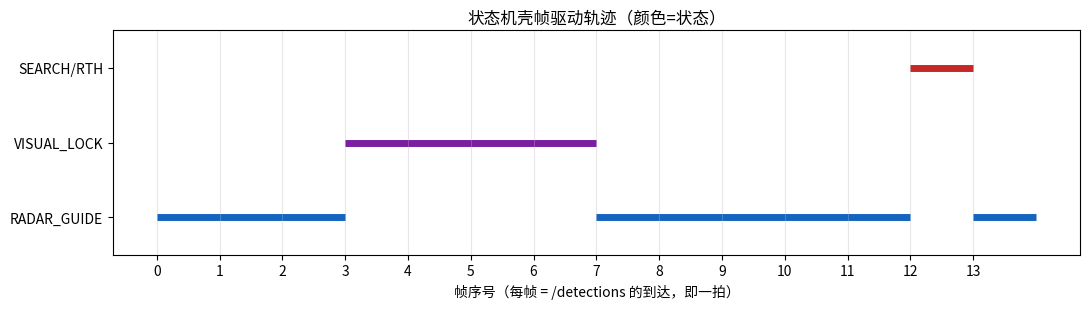

In [4]:
# 状态轨迹图：颜色 = 状态（沿用 design 模块配色）
C_RADAR = '#1565c0'   # 雷达引导蓝
C_VISUAL = '#7b1fa2'  # 视觉锁定紫
C_SEARCH = '#c62828'  # SEARCH/RTH 兜底红
STATE_COLOR = {
    sm.STATE_RADAR_GUIDE: C_RADAR,
    sm.STATE_VISUAL_LOCK: C_VISUAL,
    sm.STATE_SEARCH_RTH: C_SEARCH,
}
order = {sm.STATE_RADAR_GUIDE: 0, sm.STATE_VISUAL_LOCK: 1, sm.STATE_SEARCH_RTH: 2}

plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(11, 3.2))
for i, _name, _old, new, _vl, _rl, _cnt in rows:
    ax.plot([i, i + 1], [order[new], order[new]],
            color=STATE_COLOR[new], lw=5, solid_capstyle='butt')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['RADAR_GUIDE', 'VISUAL_LOCK', 'SEARCH/RTH'])
ax.set_xticks([r[0] for r in rows])
ax.set_xlabel('帧序号（每帧 = /detections 的到达，即一拍）')
ax.set_ylim(-0.5, 2.5)
ax.set_title('状态机壳帧驱动轨迹（颜色=状态）')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 节点接线与运行方式

`StateMachineNode` 的接线（事件驱动、无定时器）：

| 方向 | 话题 | 消息 | 作用 |
|---|---|---|---|
| 订阅 | `/detections` | `Detections` | **唯一节拍**：每帧触发一次判定 |
| 订阅 | `/visual/tracks` | `VisualTrackArray` | 仅刷新缓存 |
| 订阅 | `/radar/tracks` | `TrackArray` | 仅刷新缓存 |
| 发布 | `/state` | `std_msgs/String` | **按变化发布**（启动先发一次初值） |

参数（rosparam，`launch` / 命令行可调，不改库源码）：`~conf_thresh`、`~area_thresh`、`~n_visual_lock`、`~m_visual_lost`、`~k_radar_lost`。

运行：

```bash
source /opt/ros/noetic/setup.bash && source catkin_ws/devel/setup.bash
rosrun uav_tracking state_machine_node.py _n_visual_lock:=3 _k_radar_lost:=5
```

In [5]:
# 壳的接线常量一览（与节点实现一致）
print('订阅:', node.TOPIC_DETECTIONS, '(节拍) |', node.TOPIC_VISUAL_TRACKS, '|', node.TOPIC_RADAR_TRACKS)
print('发布:', node.TOPIC_STATE, '| 初值:', node.INITIAL_STATE, '| queue_size:', node.QUEUE_SIZE)
print('默认阈值:', 'conf=%.2f' % node.CONF_THRESH_DEFAULT, 'area=%.3f' % node.AREA_THRESH_DEFAULT)

订阅: /detections (节拍) | /visual/tracks | /radar/tracks
发布: /state | 初值: RADAR_GUIDE | queue_size: 1
默认阈值: conf=0.80 area=0.020
